# IT Incident Trend Analysis
**Dataset:** UCI Incident Management Process Enriched Event Log  
**Tools:** Python, pandas, matplotlib, seaborn  
**Author:** Ankitha B Naik

---

## Project Overview
This notebook analyzes IT incident management patterns using a real-world ITSM dataset.  
The dataset contains 141,712 rows across 24,918 unique incidents.  
Each incident can appear multiple times — one row per ticket modification (field updates, reassignments, or state changes).

### Key questions answered:
1. Which incident categories have the highest volume?
2. How are incidents distributed across priority levels?
3. Do higher-priority incidents get resolved faster?
4. What is the SLA compliance rate by priority?
5. How does incident volume trend over time?

---
## Section 1 — Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Note: Raw file (435MB) not included in repo
# Download from: https://archive.ics.uci.edu/dataset/498/incident+management+process+enriched+event+log
df = pd.read_csv('incident_event_log.csv')

print('Dataset loaded!')
print('Shape:', df.shape)
df.info()

Dataset loaded!
Shape: (141712, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141712 non-null  object
 1   incident_state           141712 non-null  object
 2   active                   141712 non-null  bool  
 3   reassignment_count       141712 non-null  int64 
 4   reopen_count             141712 non-null  int64 
 5   sys_mod_count            141712 non-null  int64 
 6   made_sla                 141712 non-null  bool  
 7   caller_id                141712 non-null  object
 8   opened_by                141712 non-null  object
 9   opened_at                141712 non-null  object
 10  sys_created_by           141712 non-null  object
 11  sys_created_at           141712 non-null  object
 12  sys_updated_by           141712 non-null  object
 13  sys_updated_at           141712 non-nu

In [3]:
# Remove -100 state — 5 records with system error/invalid state code
df = df[df['incident_state'] != '-100']
print(f"Removed -100 state records. Remaining rows: {len(df)}")

Removed -100 state records. Remaining rows: 141707


**Initial observations:**
- 141,712 rows x 36 columns loaded, 141,707 rows after removing 5 invalid records
- Date columns (opened_at, resolved_at, closed_at) stored as object/text — need conversion
- made_sla is boolean (True/False) — will be used for SLA compliance analysis
- Most columns show as object type — dataset contains significant placeholder values ('?') for missing data

---
## Section 2 — Data Cleaning & Deduplication

In [4]:
# Understand incident states in the dataset
print('Incident state distribution:')
print(df['incident_state'].value_counts())

Incident state distribution:
incident_state
Active                38716
New                   36407
Resolved              25751
Closed                24985
Awaiting User Info    14642
Awaiting Vendor         707
Awaiting Problem        461
Awaiting Evidence        38
Name: count, dtype: int64


**State distribution notes:**
- Not every incident passes through all states — a ticket can move New > Resolved > Closed, skipping Active
- Some tickets stay in intermediate states (Awaiting User Info, Awaiting Vendor etc.)
- **-100 state (5 records):** Likely system error or cancelled tickets — excluded from analysis
- We filter to **Resolved and Closed only** — these are completed incidents with full resolution data
- Both included since not all resolved tickets get formally closed in this dataset

In [5]:
# Filter to Resolved and Closed incidents only
df_resolved = df[df['incident_state'].isin(['Resolved', 'Closed'])].copy()
print('Filtered shape (Resolved + Closed rows):', df_resolved.shape)

Filtered shape (Resolved + Closed rows): (50736, 36)


In [6]:
# Convert date columns from text to datetime
# errors='coerce' handles '?' placeholder values by converting them to NaT (blank date)
df_resolved['opened_at'] = pd.to_datetime(df_resolved['opened_at'], dayfirst=True, errors='coerce')
df_resolved['resolved_at'] = pd.to_datetime(df_resolved['resolved_at'], dayfirst=True, errors='coerce')
df_resolved['closed_at'] = pd.to_datetime(df_resolved['closed_at'], dayfirst=True, errors='coerce')

print('Date columns converted!')
print('Missing resolved_at values:', df_resolved['resolved_at'].isna().sum())
print('Note: These are tickets where resolver never filled in the resolved timestamp.')
print('They are excluded only from resolution time calculations, not from other analyses.')

Date columns converted!
Missing resolved_at values: 3119
Note: These are tickets where resolver never filled in the resolved timestamp.
They are excluded only from resolution time calculations, not from other analyses.


In [7]:
# Calculate resolution time in hours (resolved_at - opened_at)
df_resolved['resolution_time_hrs'] = (
    df_resolved['resolved_at'] - df_resolved['opened_at']
).dt.total_seconds() / 3600

print('Resolution time distribution (hours):')
print(df_resolved['resolution_time_hrs'].describe())

print('\nKey comparison:')
print('Mean resolution time: ', round(df_resolved['resolution_time_hrs'].mean(), 1), 'hrs (~',
      round(df_resolved['resolution_time_hrs'].mean()/24, 1), 'days)')
print('Median resolution time:', round(df_resolved['resolution_time_hrs'].median(), 1), 'hrs (~',
      round(df_resolved['resolution_time_hrs'].median()/24, 1), 'days)')

Resolution time distribution (hours):
count    47617.000000
mean       181.838996
std        535.977658
min          0.000000
25%          0.433333
50%         22.883333
75%        155.300000
max       8070.166667
Name: resolution_time_hrs, dtype: float64

Key comparison:
Mean resolution time:  181.8 hrs (~ 7.6 days)
Median resolution time: 22.9 hrs (~ 1.0 days)


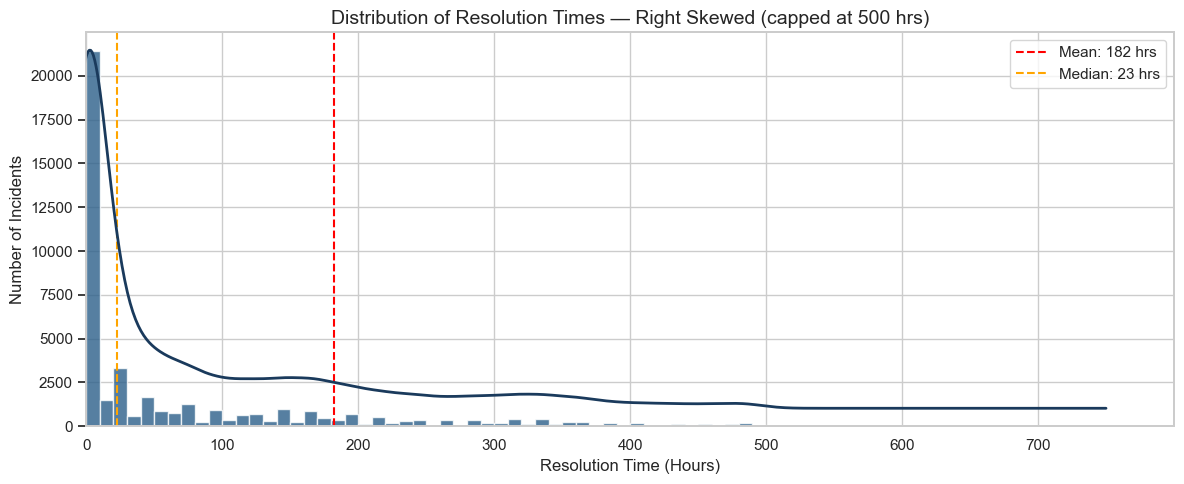

In [8]:
# Visualize the skewed distribution of resolution times
# Capping at 500 hrs for readability (extreme outliers distort the chart)

resolution_capped = df_resolved['resolution_time_hrs'].dropna()
resolution_capped = resolution_capped[resolution_capped <= 500]

plt.figure(figsize=(12, 5))

plt.hist(resolution_capped, bins=50, color='#2c5f8a', edgecolor='white', alpha=0.8)

# Overlay KDE scaled to match count axis
ax2 = plt.gca().twinx()
resolution_capped.plot.kde(ax=ax2, color='#1a3a5c', linewidth=2)
ax2.set_ylabel('')
ax2.set_yticks([])  # Hide the density axis

plt.sca(plt.gcf().axes[0])  # Switch back to main axis for lines
plt.axvline(df_resolved['resolution_time_hrs'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean: {df_resolved['resolution_time_hrs'].mean():.0f} hrs")
plt.axvline(df_resolved['resolution_time_hrs'].median(), color='orange', linestyle='--',
            linewidth=1.5, label=f"Median: {df_resolved['resolution_time_hrs'].median():.0f} hrs")

plt.title('Distribution of Resolution Times — Right Skewed (capped at 500 hrs)', fontsize=14)
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Number of Incidents')
plt.legend()
plt.xlim(left=0)
plt.tight_layout()
plt.show()

**Skewed distribution:** The chart shows most incidents resolve quickly (left side), but a long tail of slow tickets pulls the mean far right.  
Mean (182 hrs) >> Median (23 hrs) — the mean is not representative here.  
**Median will be used for all resolution time analysis in this project.**

In [9]:
# Deduplicate: keep only the FINAL state per incident
# Sort by sys_mod_count (modification count) and keep the last/most-updated row per incident
# This ensures made_sla reflects the true final outcome at ticket closure
df_dedup = df_resolved.sort_values('sys_mod_count').drop_duplicates(
    subset='number', keep='last'
)

print('Before deduplication:', df_resolved.shape[0], 'rows')
print('After deduplication:', df_dedup.shape[0], 'unique incidents')

# Verify: made_sla changes between states for many incidents
sla_change = df_resolved.groupby('number')['made_sla'].nunique()
print('\nIncidents where made_sla changed across states:', (sla_change > 1).sum(),
      f'({round((sla_change > 1).sum()/df_resolved["number"].nunique()*100, 1)}% of unique incidents)')
print('This is why the final Closed state is used as the definitive SLA measure')

Before deduplication: 50736 rows
After deduplication: 24918 unique incidents

Incidents where made_sla changed across states: 9114 (36.6% of unique incidents)
This is why the final Closed state is used as the definitive SLA measure


In [10]:
# Create time dataframe: valid resolution times only
df_time = df_dedup.dropna(subset=['resolution_time_hrs'])
df_time = df_time[df_time['resolution_time_hrs'] > 0]

print('Unique incidents available for analysis:', len(df_dedup))
print('Incidents with valid resolution time:', len(df_time))

# Export for Power BI
df_dedup.to_csv('incidents_cleaned_v2.csv', index=False)
print('Cleaned data exported to incidents_cleaned_v2.csv')

Unique incidents available for analysis: 24918
Incidents with valid resolution time: 23323
Cleaned data exported to incidents_cleaned_v2.csv


In [11]:
df_time = df_dedup.dropna(subset=['resolution_time_hrs'])
df_time = df_time[df_time['resolution_time_hrs'] > 0]
print("Missing resolution time in df_dedup:", df_dedup['resolution_time_hrs'].isna().sum())
print("Valid resolution time records (df_time):", len(df_time))

Missing resolution time in df_dedup: 1556
Valid resolution time records (df_time): 23323


**Data cleaning summary:**
- Raw rows: 141,712 → Resolved/Closed filter: 50,736 → Deduplicated: 24,918 unique incidents
- 1,556 incidents in df_dedup have missing resolved_at timestamps — excluded from resolution time calculations only, leaving 23,323 valid records for time-based analysis
- made_sla changes between states for ~36% of incidents — final state used as definitive measure
- Deduplication was essential: without it, incidents were being double/triple counted

---
## Section 3 — Analysis & Visualizations

### Analysis 1: Incident Count by Category

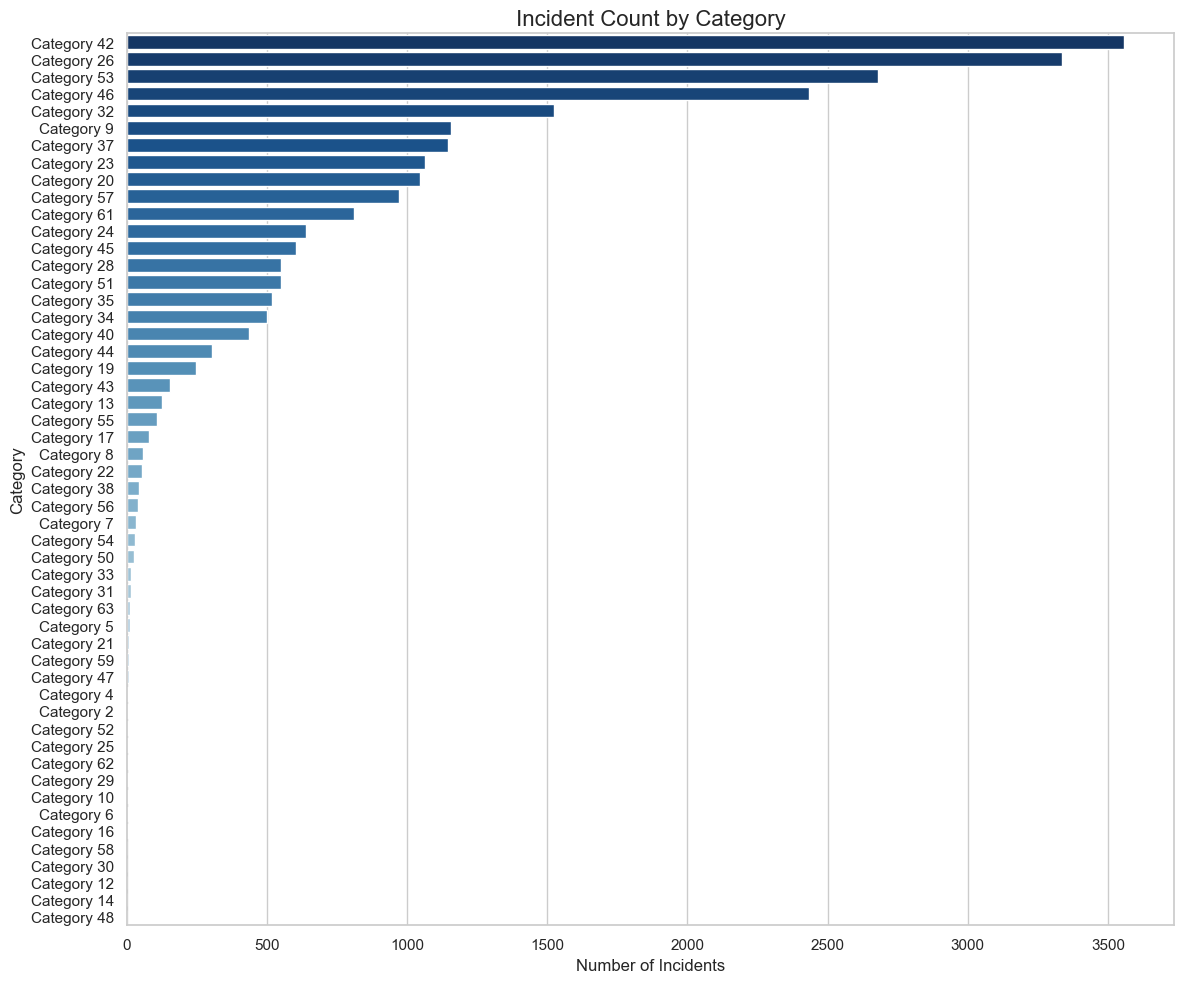

Top 5 categories:
   category  count
Category 42   3558
Category 26   3338
Category 53   2678
Category 46   2432
Category 32   1522


In [12]:
# Remove unknown category ('?')
df_clean = df_dedup[df_dedup['category'] != '?']

category_counts = df_clean['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

plt.figure(figsize=(12, 10))
sns.barplot(data=category_counts, x='count', y='category',
            hue='category', palette='Blues_r', legend=False)

plt.title('Incident Count by Category', fontsize=16)
plt.xlabel('Number of Incidents')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print('Top 5 categories:')
print(category_counts.head().to_string(index=False))

**Finding 1:** Incident volume is concentrated in a small number of categories.  
Category 42, 26, and 53 dominate — suggesting recurring systemic issues in specific areas.  
Note: Category names are anonymized in this public dataset.

### Analysis 2: Priority Distribution

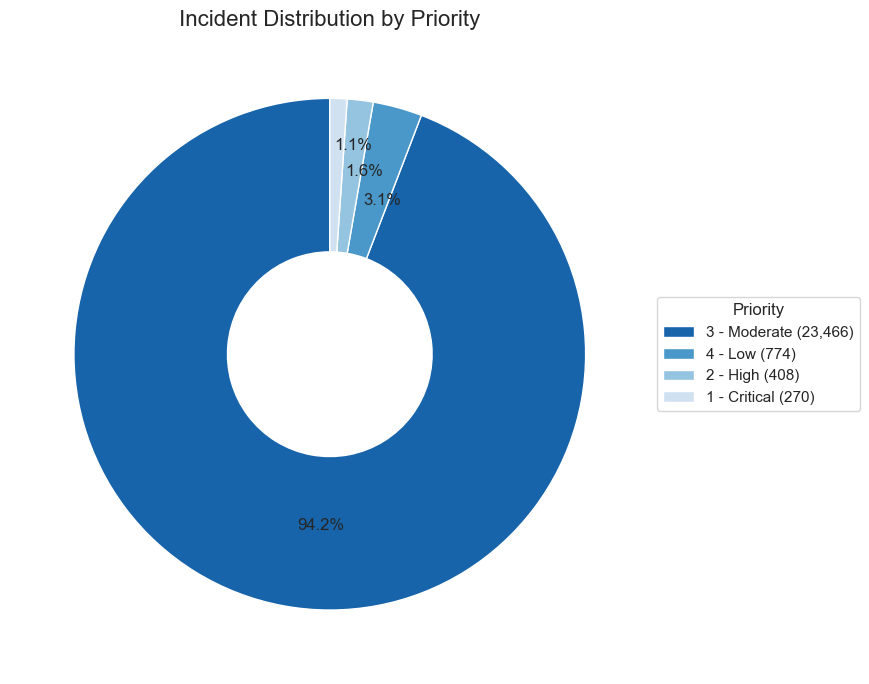

In [13]:
# Priority donut with leader lines for small slices
priority_counts = df_dedup['priority'].value_counts().reset_index()
priority_counts.columns = ['priority', 'count']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts = ax.pie(
    priority_counts['count'],
    labels=None,
    colors=sns.color_palette('Blues_r', len(priority_counts)),
    startangle=90,
    wedgeprops=dict(width=0.6)
)

# Add leader lines for all slices
total = priority_counts['count'].sum()
for i, (wedge, (_, row)) in enumerate(zip(wedges, priority_counts.iterrows())):
    angle = (wedge.theta2 + wedge.theta1) / 2
    pct = row['count'] / total * 100

    # Position label further out for small slices
    radius = 0.5 if pct < 5 else 0.7
    x = radius * plt.np.cos(plt.np.radians(angle))
    y = radius * plt.np.sin(plt.np.radians(angle))

    # Stagger small labels vertically to avoid overlap
    offset = i * 0.10 if pct < 5 else 0

    ax.annotate(
        f'{pct:.1f}%',
        xy=(plt.np.cos(plt.np.radians(angle)) * 0.85,
            plt.np.sin(plt.np.radians(angle)) * 0.85),
        xytext=(x, y + offset)
    )

ax.legend(wedges,
          [f"{row['priority']} ({row['count']:,})" for _, row in priority_counts.iterrows()],
          title='Priority',
          loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1))

ax.set_title('Incident Distribution by Priority', fontsize=16)
plt.tight_layout()
plt.show()

**Finding 2:** 94% of incidents are P3-Moderate. Only ~3% are P1/P2 combined.  
Indicates a stable environment with infrequent critical incidents.  
Note: Small slice labels hidden in chart to avoid overlap — exact counts shown in table above.

### Analysis 3: Median Resolution Time by Priority

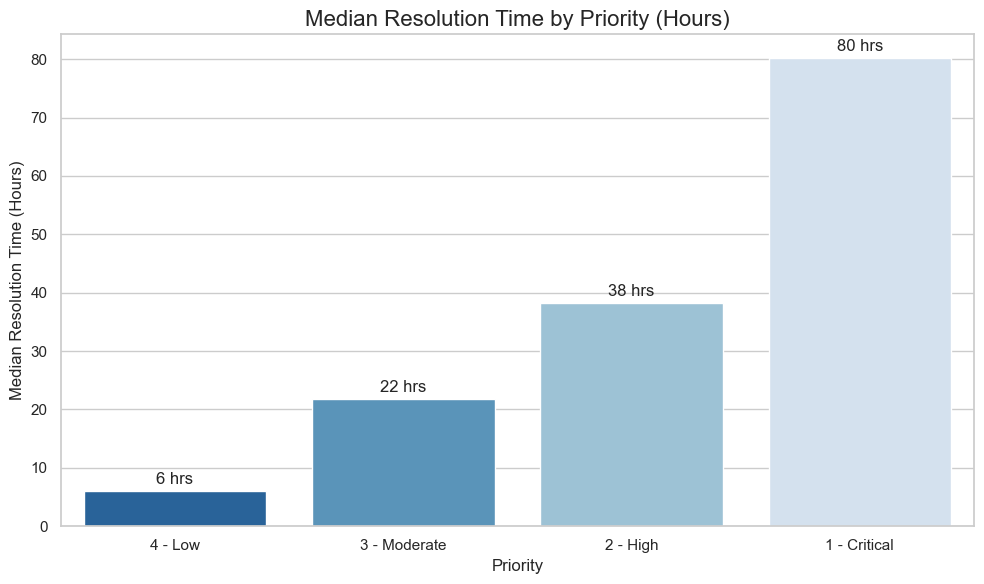

Median resolution time by priority:
    priority  median_resolution_hrs
     4 - Low               6.033333
3 - Moderate              21.716667
    2 - High              38.233333
1 - Critical              80.241667


In [14]:
# Median used (not mean) because resolution time is right-skewed (shown earlier)
priority_resolution = df_time.groupby('priority')['resolution_time_hrs'].median().reset_index()
priority_resolution.columns = ['priority', 'median_resolution_hrs']
priority_resolution = priority_resolution.sort_values('median_resolution_hrs')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=priority_resolution, x='priority', y='median_resolution_hrs',
            hue='priority', palette='Blues_r', legend=False)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f hrs', padding=3)

plt.title('Median Resolution Time by Priority (Hours)', fontsize=16)
plt.xlabel('Priority')
plt.ylabel('Median Resolution Time (Hours)')
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

print('Median resolution time by priority:')
print(priority_resolution.to_string(index=False))

**Finding 3 (Key Finding):** P1-Critical takes the LONGEST to resolve (approx. 80 hrs median), P4-Low fastest (approx. 6 hrs).  
This is the opposite of expected behavior — critical incidents should resolve fastest.  
Likely causes: P1 incidents involve greater complexity, multiple teams, and vendor escalations.

### Analysis 4: SLA Compliance

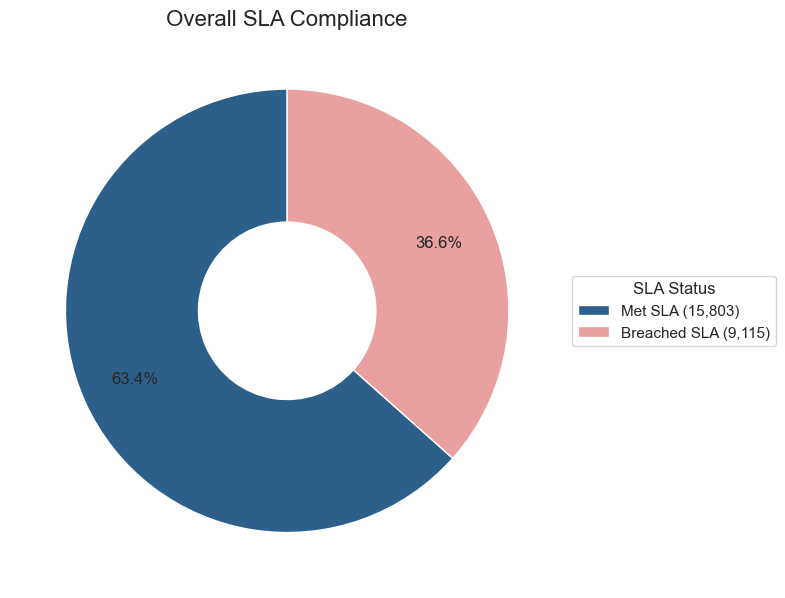

In [15]:
# Overall SLA compliance
sla_counts = df_dedup['made_sla'].value_counts().reset_index()
sla_counts.columns = ['made_sla', 'count']
sla_counts['made_sla'] = sla_counts['made_sla'].map({True: 'Met SLA', False: 'Breached SLA'})

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sla_counts['count'],
    labels=None,
    autopct='%1.1f%%',
    colors=['#2c5f8a', '#e8a0a0'],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

plt.legend(wedges, [f"{row['made_sla']} ({row['count']:,})" for _, row in sla_counts.iterrows()],
           title='SLA Status',
           loc='center left',
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Overall SLA Compliance', fontsize=16)
plt.tight_layout()
plt.show()

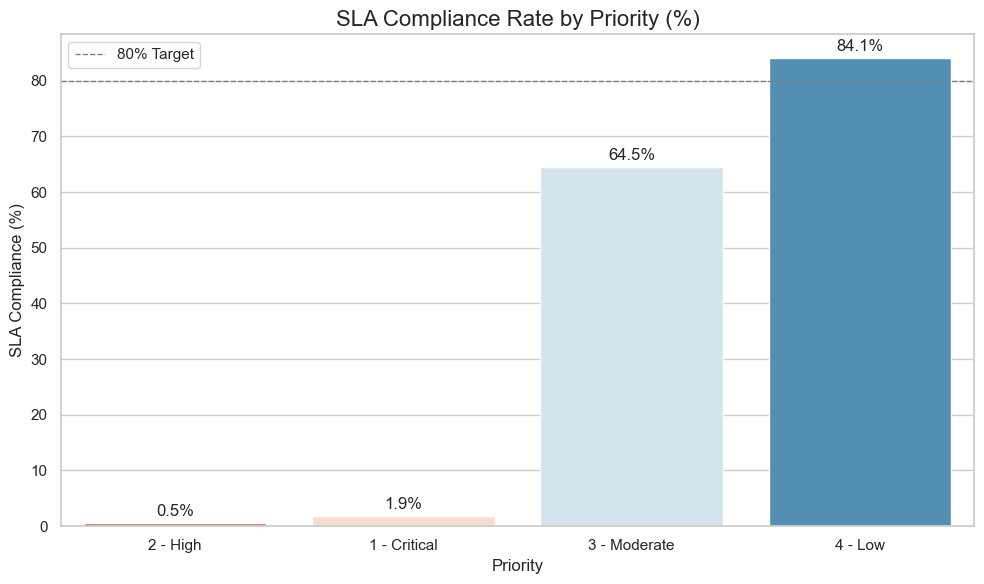

SLA compliance by priority:
    priority  sla_compliance_rate
    2 - High                 0.49
1 - Critical                 1.85
3 - Moderate                64.54
     4 - Low                84.11


In [16]:
# SLA compliance by priority
# .mean() on True/False gives compliance rate (True=1, False=0, average = proportion met)
sla_by_priority = df_dedup.groupby('priority')['made_sla'].mean().reset_index()
sla_by_priority.columns = ['priority', 'sla_compliance_rate']
sla_by_priority['sla_compliance_rate'] = sla_by_priority['sla_compliance_rate'] * 100
sla_by_priority = sla_by_priority.sort_values('sla_compliance_rate')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sla_by_priority, x='priority', y='sla_compliance_rate',
            hue='priority', palette='RdBu', legend=False)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('SLA Compliance Rate by Priority (%)', fontsize=16)
plt.xlabel('Priority')
plt.ylabel('SLA Compliance (%)')
plt.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80% Target')
plt.legend()
plt.tight_layout()
plt.show()

print('SLA compliance by priority:')
print(sla_by_priority.round(2).to_string(index=False))

**Finding 4 (Key Finding):** SLA compliance is critically low for high-priority incidents at final closure:
- P2-High: ~0.5% | P1-Critical: ~1.9% | P3-Moderate: ~64.5% | P4-Low: ~84.1%

P1 and P2 — the most business-critical incidents — are breaching SLA almost universally.  
This directly confirms Finding 3: the incidents that take longest also breach SLA most.

**Note on SLA measurement:** made_sla changes between Resolved and Closed states for ~36% of incidents.  
Final Closed state used as the definitive SLA outcome — this gives the most accurate picture.

### Analysis 5: Incident Volume Trend Over Time

In [17]:
# Use full dataset (all states), deduplicated by first occurrence (opened_at)
# This captures true incident creation volume regardless of resolution status
df_all = df.copy()
df_all['opened_at'] = pd.to_datetime(df_all['opened_at'], dayfirst=True, errors='coerce')

df_all_unique = df_all.sort_values('opened_at').drop_duplicates(
    subset='number', keep='first'
)

df_all_unique['month'] = df_all_unique['opened_at'].dt.to_period('M')
monthly_trend = df_all_unique.groupby('month').size().reset_index()
monthly_trend.columns = ['month', 'incident_count']
monthly_trend['month'] = monthly_trend['month'].astype(str)

print('Monthly incident counts:')
print(monthly_trend.to_string(index=False))

Monthly incident counts:
  month  incident_count
2016-02             207
2016-03            8995
2016-04            7934
2016-05            7508
2016-06               5
2016-07              14
2016-08              15
2016-09              12
2016-10              16
2016-11              26
2016-12              37
2017-01              94
2017-02              55


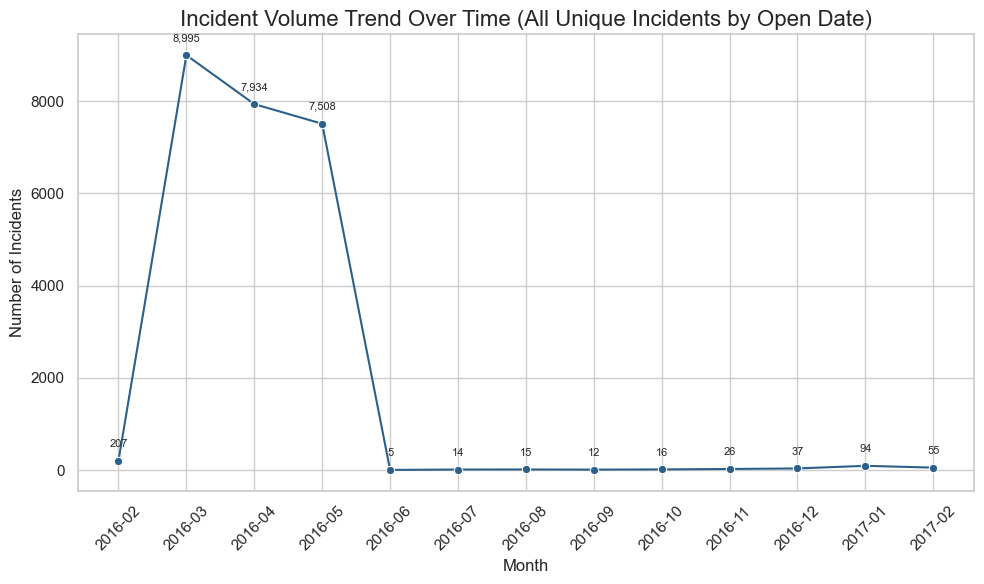

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=monthly_trend, x='month', y='incident_count',
                  marker='o', color='#2c5f8a')

# Label ALL data points
for i, row in monthly_trend.iterrows():
    if row['incident_count'] > 0:
        ax.annotate(f"{int(row['incident_count']):,}",
                    xy=(row['month'], row['incident_count']),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=8)

plt.title('Incident Volume Trend Over Time (All Unique Incidents by Open Date)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding 5:** Dataset is heavily concentrated in Feb-May 2016 (~99% of all incidents).  
Only 274 genuine incidents exist beyond June 2016 — likely a minimal second data collection phase.  

Within the reliable Feb-May 2016 window: mild declining trend from 8,995 (March) to 7,508 (May) — ~17% reduction.  

**Data limitation:** Trend analysis beyond May 2016 is not meaningful due to sparse data coverage.

---
## Section 4 — Summary of Key Findings

| # | Finding | Insight |
|---|---|---|
| 1 | Category Concentration | Top 3 categories (42, 26, 53) dominate incident volume |
| 2 | Priority Distribution | 94% of incidents are P3-Moderate; only ~3% are P1/P2 |
| 3 | Resolution Time Anomaly | P1-Critical takes longest (approx.80 hrs); P4-Low fastest (approx.6 hrs) |
| 4 | SLA Compliance Crisis | P1/P2 have less than 2% SLA compliance; P4-Low has 84% |
| 5 | Volume Trend | Mild declining trend Mar-May 2016; data sparse beyond June 2016 |

**Core business insight:** The most critical incidents (P1/P2) are both slowest to resolve  
and most likely to breach SLA — suggesting a misalignment between SLA targets and actual  
incident complexity, or resources being directed toward easier tickets over critical ones.